# Notebook 02 — UK Gilt Yield Curve

## Purpose
Construct the UK gilt yield curve across four maturities and analyse its evolution 2016–2026. 
Identify key structural inflection points and classify major curve moves. 
Incorporate carry and roll-down analysis.

## Research Question
How did the shape and level of the UK gilt yield curve evolve through the inflation cycle, 
and what did each major move imply for fixed income portfolios?

## Key Analysis
- Yield curve construction: 2yr, 5yr, 10yr, 30yr
- 2/10 spread and 5/30 spread — curve slope through the cycle
- Bear steepening vs bull steepening identification at key inflection points
- Duration impact — translating yield moves into portfolio price returns
- Carry and roll-down across maturities in different curve environments
- Total return decomposition: price return + coupon + roll

## Reads from
`/data/processed/uk_gilts_nominal.csv`

In [34]:
# ============================================================
# SETUP — WORKING DIRECTORY, IMPORTS, LOAD DATA
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os

# Fix working directory — must run at start of every notebook
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

print(f"Working directory: {os.getcwd()}")

# Load UK nominal gilt spot curve
gilts = pd.read_csv('data/processed/uk_gilts_nominal.csv', 
                    index_col=0, parse_dates=True)

print(f"Gilt data loaded: {gilts.shape}")
print(f"Date range: {gilts.index[0].date()} to {gilts.index[-1].date()}")
print(f"\nFirst 3 rows:")
print(gilts.head(3))

Working directory: C:\Users\tomsu\Documents\Graduate Jobs\CV PROJECTS\uk-gilt-market-analysis
Gilt data loaded: (2589, 4)
Date range: 2016-01-04 to 2026-03-31

First 3 rows:
              uk_2yr    uk_5yr   uk_10yr   uk_30yr
0                                                 
2016-01-04  0.611093  1.297485  1.934177  2.684496
2016-01-05  0.593339  1.282928  1.929885  2.679990
2016-01-06  0.534982  1.210266  1.844250  2.614465


In [2]:
# ============================================================
# YIELD CURVE SLOPE MEASURES
# ============================================================

# 2/10 spread — most widely watched curve slope measure
# Positive = normal curve, Negative = inverted curve
gilts['spread_2_10'] = gilts['uk_10yr'] - gilts['uk_2yr']

# 5/30 spread — shape of the long end specifically
# More sensitive to long-run inflation expectations and fiscal risk
gilts['spread_5_30'] = gilts['uk_30yr'] - gilts['uk_5yr']

# Quick summary of spreads at key dates
key_dates = {
    'Jan 2016 (start)':        '2016-01-04',
    'Jun 2016 (Brexit vote)':  '2016-06-24',
    'Mar 2020 (COVID)':        '2020-03-23',
    'Jan 2022 (pre-hikes)':    '2022-01-03',
    'Sep 2022 (Truss)':        '2022-09-23',
    'Dec 2023 (peak rates)':   '2023-12-01',
    'Apr 2026 (current)':      gilts.index[-1].strftime('%Y-%m-%d'),
}

print(f"{'Date':<28} {'2yr':>7} {'5yr':>7} {'10yr':>7} {'30yr':>7} {'2/10':>7} {'5/30':>7}")
print("-" * 77)
for label, date in key_dates.items():
    # Find nearest available date
    idx = gilts.index.get_indexer([pd.Timestamp(date)], method='nearest')[0]
    row = gilts.iloc[idx]
    print(f"{label:<28} {row['uk_2yr']:>7.2f} {row['uk_5yr']:>7.2f} "
          f"{row['uk_10yr']:>7.2f} {row['uk_30yr']:>7.2f} "
          f"{row['spread_2_10']:>7.2f} {row['spread_5_30']:>7.2f}")

Date                             2yr     5yr    10yr    30yr    2/10    5/30
-----------------------------------------------------------------------------
Jan 2016 (start)                0.61    1.30    1.93    2.68    1.32    1.39
Jun 2016 (Brexit vote)          0.21    0.57    1.22    1.99    1.01    1.43
Mar 2020 (COVID)                0.05    0.14    0.39    0.74    0.34    0.60
Jan 2022 (pre-hikes)            0.71    0.86    1.08    1.21    0.38    0.35
Sep 2022 (Truss)                3.97    3.96    3.84    3.95   -0.13   -0.02
Dec 2023 (peak rates)           4.32    3.97    4.17    4.67   -0.15    0.71
Apr 2026 (current)              4.28    4.41    4.94    5.63    0.66    1.23


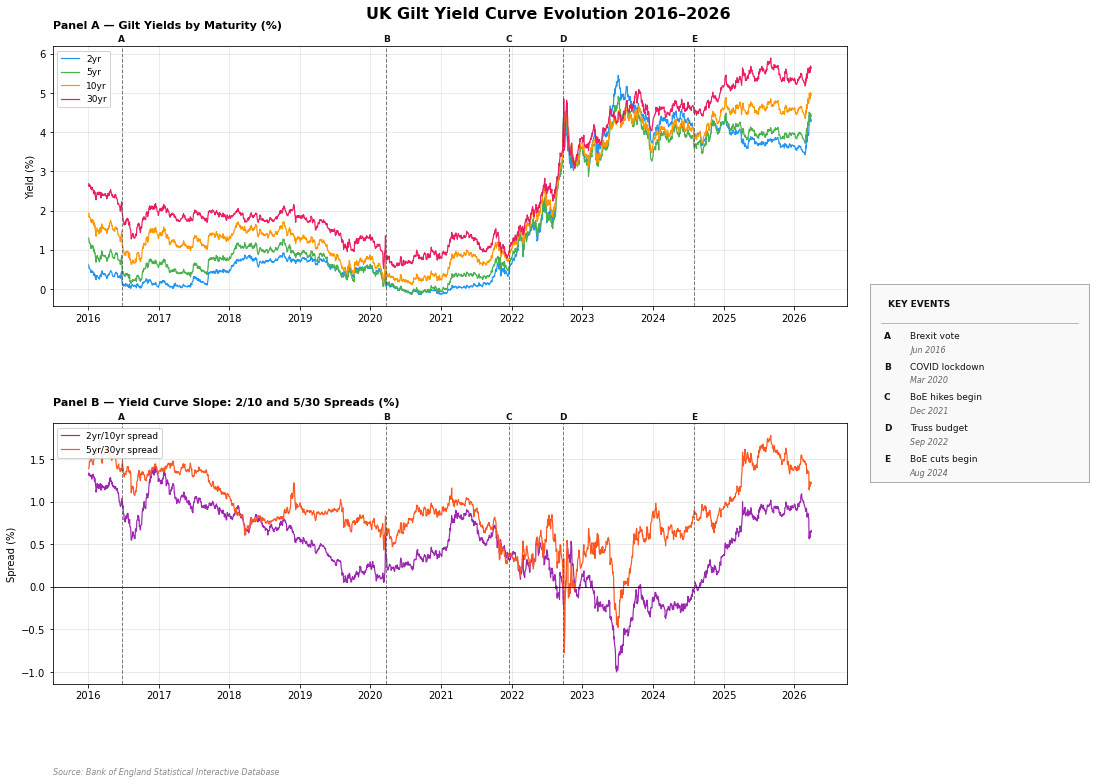

Chart saved.


In [19]:
fig, axes = plt.subplots(2, 1, figsize=(16, 11), facecolor='white')
fig.subplots_adjust(top=0.93, hspace=0.45, right=0.76, left=0.07)
fig.suptitle('UK Gilt Yield Curve Evolution 2016–2026',
             fontsize=16, fontweight='bold', y=0.98)

event_dates = {
    'A': ('Brexit vote',     '2016-06-24'),
    'B': ('COVID lockdown',  '2020-03-23'),
    'C': ('BoE hikes begin', '2021-12-16'),
    'D': ('Truss budget',    '2022-09-23'),
    'E': ('BoE cuts begin',  '2024-08-01'),
}

ax1 = axes[0]
ax1.set_facecolor('white')

for col, color in colors_dict.items():
    ax1.plot(gilts.index.to_pydatetime(), gilts[col].values,
             color=color, linewidth=1.2, label=labels_dict[col])

for letter, (label, date) in event_dates.items():
    idx = gilts.index.get_indexer([pd.Timestamp(date)], method='nearest')[0]
    x = gilts.index[idx].to_pydatetime()
    ax1.axvline(x=x, color='#444444', linestyle='--', linewidth=1.0, alpha=0.7)
    ax1.text(x, 1.01, letter, fontsize=9, ha='center', va='bottom',
             color='#111111', fontweight='bold',
             transform=ax1.get_xaxis_transform())

ax1.set_title('Panel A — Gilt Yields by Maturity (%)',
              fontsize=11, fontweight='bold', loc='left', pad=18)
ax1.set_ylabel('Yield (%)', fontsize=10)
ax1.legend(loc='upper left', fontsize=9, framealpha=0.9)
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.xaxis.set_major_locator(mdates.YearLocator())

ax2 = axes[1]
ax2.set_facecolor('white')
ax2.plot(gilts.index.to_pydatetime(), gilts['spread_2_10'].values,
         color='#9C27B0', linewidth=1.2, label='2yr/10yr spread')
ax2.plot(gilts.index.to_pydatetime(), gilts['spread_5_30'].values,
         color='#FF5722', linewidth=1.2, label='5yr/30yr spread')
ax2.axhline(y=0, color='black', linewidth=0.8, linestyle='-')

for letter, (label, date) in event_dates.items():
    idx = gilts.index.get_indexer([pd.Timestamp(date)], method='nearest')[0]
    x = gilts.index[idx].to_pydatetime()
    ax2.axvline(x=x, color='#444444', linestyle='--', linewidth=1.0, alpha=0.7)
    ax2.text(x, 1.01, letter, fontsize=9, ha='center', va='bottom',
             color='#111111', fontweight='bold',
             transform=ax2.get_xaxis_transform())

ax2.set_title('Panel B — Yield Curve Slope: 2/10 and 5/30 Spreads (%)',
              fontsize=11, fontweight='bold', loc='left', pad=18)
ax2.set_ylabel('Spread (%)', fontsize=10)
ax2.legend(loc='upper left', fontsize=9, framealpha=0.9)
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.xaxis.set_major_locator(mdates.YearLocator())

# Key events legend box
ax_legend = fig.add_axes([0.78, 0.38, 0.19, 0.25], facecolor='#f9f9f9')
ax_legend.set_xticks([])
ax_legend.set_yticks([])
ax_legend.set_xlim(0, 1)
ax_legend.set_ylim(0, 1)
for spine in ax_legend.spines.values():
    spine.set_edgecolor('#aaaaaa')
    spine.set_linewidth(1.0)

# Header
ax_legend.text(0.08, 0.92, 'KEY EVENTS',
               transform=ax_legend.transAxes,
               fontsize=9, fontweight='bold',
               va='top', color='#111111')

# Line under header — use plot instead of axhline
ax_legend.plot([0.05, 0.95], [0.80, 0.80], color='#aaaaaa',
               linewidth=0.8, transform=ax_legend.transAxes)

# Entries
entries = [
    ('A', 'Brexit vote',     'Jun 2016'),
    ('B', 'COVID lockdown',  'Mar 2020'),
    ('C', 'BoE hikes begin', 'Dec 2021'),
    ('D', 'Truss budget',    'Sep 2022'),
    ('E', 'BoE cuts begin',  'Aug 2024'),
]

for i, (letter, desc, date) in enumerate(entries):
    y = 0.76 - i * 0.155
    ax_legend.text(0.06, y, letter, transform=ax_legend.transAxes,
                   fontsize=9, fontweight='bold', va='top', color='#111111')
    ax_legend.text(0.18, y, desc, transform=ax_legend.transAxes,
                   fontsize=9, va='top', color='#111111')
    ax_legend.text(0.18, y - 0.07, date, transform=ax_legend.transAxes,
                   fontsize=8, va='top', color='#666666', style='italic')

fig.text(0.07, 0.01, 'Source: Bank of England Statistical Interactive Database',
         fontsize=8, color='#888888', style='italic')

plt.savefig('outputs/charts/01_gilt_yield_curve_evolution.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Chart saved.")

In [23]:
# ============================================================
# YIELD CURVE REGIME SUMMARY TABLE
# ============================================================

regimes = [
    {
        'period':    'Jan 2016 – Jun 2016',
        'start':     '2016-01-04',
        'end':       '2016-06-23',
        'regime':    'Bear flattening',
        'driver':    'Brexit uncertainty — short end anchored by BoE, long end repricing growth risk'
    },
    {
        'period':    'Jun 2016 – Aug 2016',
        'start':     '2016-06-24',
        'end':       '2016-08-03',
        'regime':    'Bull steepening',
        'driver':    'Post-Brexit shock — BoE emergency cut, short end collapses faster than long end'
    },
    {
        'period':    'Aug 2016 – Dec 2019',
        'start':     '2016-08-04',
        'end':       '2019-12-31',
        'regime':    'Gradual flattening',
        'driver':    'Low rate era — range-bound yields, modest BoE normalisation attempt 2017-2018'
    },
    {
        'period':    'Jan 2020 – Aug 2020',
        'start':     '2020-01-01',
        'end':       '2020-08-31',
        'regime':    'Bull flattening',
        'driver':    'COVID — emergency BoE cuts and QE, entire curve collapses toward zero'
    },
    {
        'period':    'Aug 2020 – Dec 2021',
        'start':     '2020-09-01',
        'end':       '2021-11-30',
        'regime':    'Bear steepening',
        'driver':    'Recovery and inflation emergence — long end repricing inflation, short end anchored by BoE forward guidance'
    },
    {
        'period':    'Dec 2021 – Sep 2022',
        'start':     '2021-12-01',
        'end':       '2022-09-22',
        'regime':    'Bear flattening',
        'driver':    'BoE hiking cycle — short end rises sharply with policy rate, long end rises but less so'
    },
    {
        'period':    'Sep 2022 – Oct 2022',
        'start':     '2022-09-23',
        'end':       '2022-10-31',
        'regime':    'Bear steepening',
        'driver':    'Truss mini-budget — long end blows out on fiscal risk premium, doom loop dynamics'
    },
    {
        'period':    'Nov 2022 – Jul 2023',
        'start':     '2022-11-01',
        'end':       '2023-07-31',
        'regime':    'Bear flattening',
        'driver':    'Continued BoE hikes to combat persistent inflation — curve inverts'
    },
    {
        'period':    'Aug 2023 – Jul 2024',
        'start':     '2023-08-01',
        'end':       '2024-07-31',
        'regime':    'Bull steepening',
        'driver':    'Peak rates — markets pricing BoE cuts, short end falls faster than long end'
    },
    {
        'period':    'Aug 2024 – present',
        'start':     '2024-08-01',
        'end':       gilts.index[-1].strftime('%Y-%m-%d'),
        'regime':    'Bull steepening',
        'driver':    'BoE cutting cycle underway — short end declining, long end elevated on fiscal and inflation risk'
    },
]

# Calculate 2/10 spread at start and end of each regime
print(f"{'Period':<25} {'Regime':<20} {'2/10 Start':>10} {'2/10 End':>10} {'Change':>8}")
print("=" * 80)

for r in regimes:
    start_idx = gilts.index.get_indexer([pd.Timestamp(r['start'])], method='nearest')[0]
    end_idx   = gilts.index.get_indexer([pd.Timestamp(r['end'])],   method='nearest')[0]
    
    spread_start = gilts.iloc[start_idx]['spread_2_10']
    spread_end   = gilts.iloc[end_idx]['spread_2_10']
    change       = spread_end - spread_start
    
    # Store for later use
    r['spread_start'] = spread_start
    r['spread_end']   = spread_end
    r['change']       = change
    
    print(f"{r['period']:<25} {r['regime']:<20} "
          f"{spread_start:>+10.2f} {spread_end:>+10.2f} {change:>+8.2f}")

print("\nAll values in percentage points")

Period                    Regime               2/10 Start   2/10 End   Change
Jan 2016 – Jun 2016       Bear flattening           +1.32      +1.03    -0.29
Jun 2016 – Aug 2016       Bull steepening           +1.01      +0.79    -0.22
Aug 2016 – Dec 2019       Gradual flattening        +0.70      +0.29    -0.41
Jan 2020 – Aug 2020       Bull flattening           +0.25      +0.44    +0.19
Aug 2020 – Dec 2021       Bear steepening           +0.44      +0.39    -0.05
Dec 2021 – Sep 2022       Bear flattening           +0.37      +0.03    -0.34
Sep 2022 – Oct 2022       Bear steepening           -0.13      +0.28    +0.41
Nov 2022 – Jul 2023       Bear flattening           +0.35      -0.69    -1.04
Aug 2023 – Jul 2024       Bull steepening           -0.66      -0.05    +0.61
Aug 2024 – present        Bull steepening           -0.06      +0.66    +0.73

All values in percentage points


## Total Return Decomposition by Maturity and Regime

Calculates total return for a par gilt at each maturity (2yr, 5yr, 10yr, 30yr) 
across each major yield curve regime period 2016–2026.

**Three components:**
- **Price return** — full bond pricing formula (captures convexity)
- **Coupon income** — coupon assumed equal to starting yield (par bond assumption)
- **Roll-down return** — return from riding the yield curve as maturity shortens

**Key assumptions:**
- Par bond at start of each period (coupon = starting yield)
- Clean prices throughout (no accrued interest)
- Coupons not reinvested
- Roll-down calculated assuming stable curve shape over the period

 Limitations noted where material.

In [40]:
# ============================================================
# TOTAL RETURN DECOMPOSITION — BOND PRICING FUNCTIONS
# ============================================================

def price_bond(yield_annual, coupon_annual, maturity_years, face=100):
    """
    Price a fixed coupon bond using full discounted cashflow formula.
    
    Parameters:
    -----------
    yield_annual  : annual yield (e.g. 0.05 for 5%)
    coupon_annual : annual coupon rate (e.g. 0.05 for 5%)
    maturity_years: years to maturity (e.g. 10)
    face          : face value (default 100)
    
    Returns:
    --------
    Clean price of the bond
    
    Method:
    -------
    UK gilts pay semi-annual coupons. We discount each semi-annual
    cashflow at the semi-annual yield. This is the standard UK gilt
    pricing convention.
    """
    # Convert to semi-annual
    y = yield_annual / 2          # semi-annual yield
    c = (coupon_annual / 2) * face # semi-annual coupon payment
    n = int(maturity_years * 2)    # number of semi-annual periods
    
    if n == 0:
        return face
    
    # Price = PV of coupons + PV of face value
    # PV of coupons = c * [1 - (1+y)^-n] / y  (annuity formula)
    # PV of face    = face * (1+y)^-n
    
    if y == 0:
        price = c * n + face
    else:
        pv_coupons = c * (1 - (1 + y) ** (-n)) / y
        pv_face    = face * (1 + y) ** (-n)
        price      = pv_coupons + pv_face
    
    return price


def get_spot_yield(gilts_df, date, maturity):
    """
    Get spot yield at a specific date and maturity.
    Interpolates between available maturities.
    For maturities below 2yr, linearly extrapolates 
    between BoE rate proxy and 2yr yield.
    """
    import os
    
    idx = gilts_df.index.get_indexer([pd.Timestamp(date)], method='nearest')[0]
    row = gilts_df.iloc[idx]
    
    available = {
        2:  row['uk_2yr'],
        5:  row['uk_5yr'],
        10: row['uk_10yr'],
        30: row['uk_30yr'],
    }
    
    # Exact match
    if maturity in available:
        return available[maturity] / 100
    
    # Below 2yr — extrapolate using BoE rate as anchor at 0yr
    if maturity < 2:
        # Load BoE rate and find nearest date
        boe = pd.read_csv('data/processed/boe_rate.csv', 
                          index_col=0, parse_dates=True)
        boe_idx = boe.index.get_indexer([pd.Timestamp(date)], method='nearest')[0]
        boe_rate = boe.iloc[boe_idx].values[0]
        
        # Linear interpolation between BoE rate (at 0yr) and 2yr yield
        y2 = available[2]
        interpolated = boe_rate + (y2 - boe_rate) * (maturity / 2)
        return interpolated / 100
    
    # Between known maturities — linear interpolation
    mats = sorted(available.keys())
    for i in range(len(mats) - 1):
        if mats[i] < maturity < mats[i+1]:
            y0, y1 = available[mats[i]], available[mats[i+1]]
            m0, m1 = mats[i], mats[i+1]
            interpolated = y0 + (y1 - y0) * (maturity - m0) / (m1 - m0)
            return interpolated / 100
    
    # Beyond 30yr — return 30yr yield
    return available[30] / 100


# Quick sanity check — price a par bond
# A par bond (coupon = yield) should price at exactly 100
test_yield  = 0.05  # 5%
test_coupon = 0.05  # 5% coupon
test_price  = price_bond(test_yield, test_coupon, 10)
print(f"Par bond sanity check (10yr, 5% yield, 5% coupon):")
print(f"  Price: £{test_price:.4f} (should be exactly £100.00)")

# Test a bond where yield has risen — price should be below par
test_price2 = price_bond(0.06, 0.05, 10)
print(f"\nYield risen to 6% (bond should be below par):")
print(f"  Price: £{test_price2:.4f}")

# Test a bond where yield has fallen — price should be above par
test_price3 = price_bond(0.04, 0.05, 10)
print(f"\nYield fallen to 4% (bond should be above par):")
print(f"  Price: £{test_price3:.4f}")

Par bond sanity check (10yr, 5% yield, 5% coupon):
  Price: £100.0000 (should be exactly £100.00)

Yield risen to 6% (bond should be below par):
  Price: £92.5613

Yield fallen to 4% (bond should be above par):
  Price: £108.1757


In [41]:
# ============================================================
# TOTAL RETURN DECOMPOSITION BY REGIME AND MATURITY
# ============================================================

def calculate_total_return(gilts_df, start_date, end_date, maturity):
    """
    Calculate total return for a par gilt over a holding period.
    
    Components:
    1. Price return    — full bond pricing formula, par bond assumption
    2. Coupon income   — starting yield as coupon proxy, scaled to period length
    3. Roll-down       — return from riding the yield curve as maturity shortens
    
    Parameters:
    -----------
    gilts_df     : DataFrame with gilt yields
    start_date   : start of holding period
    end_date     : end of holding period
    maturity     : gilt maturity in years (2, 5, 10, 30)
    
    Returns:
    --------
    dict with price_return, coupon_return, rolldown_return, total_return (all in %)
    """
    
    # --- SETUP ---
    # Get yields at start and end
    y_start = get_spot_yield(gilts_df, start_date, maturity)
    y_end   = get_spot_yield(gilts_df, end_date,   maturity)
    
    # Calculate holding period in years
    start_ts = pd.Timestamp(start_date)
    end_ts   = pd.Timestamp(end_date)
    holding_years = (end_ts - start_ts).days / 365.25
    
    # --- COMPONENT 1: PRICE RETURN ---
    # Par bond: coupon = starting yield, price starts at 100
    # Reprice at end of period using ending yield
    # Remaining maturity at end = original maturity - holding period
    remaining_maturity = max(maturity - holding_years, 0.5)
    
    price_start = 100.0  # Par bond by definition
    price_end   = price_bond(y_end, y_start, remaining_maturity)
    
    price_return = (price_end - price_start) / price_start * 100
    
    # --- COMPONENT 2: COUPON INCOME ---
    # Annual coupon = starting yield * face value
    # Scaled to holding period length
    coupon_return = y_start * holding_years * 100
    
    # --- COMPONENT 3: ROLL-DOWN RETURN ---
    # Isolate the return from riding the curve assuming curve DOESN'T move
    # i.e. reprice the bond at the rolled maturity using the START DATE curve
    # Compare to starting price of 100
    # Roll-down = price at (maturity - holding_years) on start curve - 100
    
    y_rolled = get_spot_yield(gilts_df, start_date, remaining_maturity)
    price_rolled = price_bond(y_rolled, y_start, remaining_maturity)
    rolldown_return = (price_rolled - price_start) / price_start * 100
    
    # Note: price_return already includes roll-down implicitly
    # We need to isolate pure yield-change price return
    # Pure price return = total price change - roll-down component
    pure_price_return = price_return - rolldown_return
    
    return {
        'price_return':    round(pure_price_return, 2),
        'coupon_return':   round(coupon_return, 2),
        'rolldown_return': round(rolldown_return, 2),
        'total_return':    round(pure_price_return + coupon_return + rolldown_return, 2),
        'yield_change_bps': round((y_end - y_start) * 10000, 1),
        'holding_years':   round(holding_years, 2),
    }



In [42]:
# ============================================================
# ANNUAL TOTAL RETURN BY MATURITY — 2016 to 2025
# ============================================================

# Calendar year start and end dates
# Use first and last available trading day each year
years = range(2016, 2026)  # 2016-2025 inclusive
maturities = [2, 5, 10, 30]

# Get first and last trading day for each year
year_dates = {}
for year in years:
    year_data = gilts[gilts.index.year == year]
    if len(year_data) > 0:
        year_dates[year] = {
            'start': year_data.index[0].strftime('%Y-%m-%d'),
            'end':   year_data.index[-1].strftime('%Y-%m-%d')
        }
        
print("Year windows confirmed:")
for year, dates in year_dates.items():
    print(f"  {year}: {dates['start']} to {dates['end']}")

Year windows confirmed:
  2016: 2016-01-04 to 2016-12-30
  2017: 2017-01-03 to 2017-12-29
  2018: 2018-01-02 to 2018-12-31
  2019: 2019-01-02 to 2019-12-31
  2020: 2020-01-02 to 2020-12-31
  2021: 2021-01-04 to 2021-12-31
  2022: 2022-01-04 to 2022-12-30
  2023: 2023-01-03 to 2023-12-29
  2024: 2024-01-02 to 2024-12-31
  2025: 2025-01-02 to 2025-12-31


In [33]:
# Sense check — 2016 30yr return
check = calculate_total_return(gilts, '2016-01-04', '2016-12-30', 30)
print("2016 30yr detailed breakdown:")
for k, v in check.items():
    print(f"  {k}: {v}")

2016 30yr detailed breakdown:
  price_return: 16.78
  coupon_return: 2.65
  rolldown_return: 0.75
  total_return: 20.18
  yield_change_bps: -78.9
  holding_years: 0.99


In [43]:
# ============================================================
# ANNUAL TOTAL RETURN BY MATURITY — 2016 to 2025
# ============================================================

maturities = [2, 5, 10, 30]
years = range(2016, 2026)

# Get first and last trading day for each year
year_dates = {}
for year in years:
    year_data = gilts[gilts.index.year == year]
    if len(year_data) > 0:
        year_dates[year] = {
            'start': year_data.index[0].strftime('%Y-%m-%d'),
            'end':   year_data.index[-1].strftime('%Y-%m-%d')
        }

# Calculate annual total returns
annual_results = []

for year, dates in year_dates.items():
    for mat in maturities:
        ret = calculate_total_return(
            gilts, dates['start'], dates['end'], mat
        )
        annual_results.append({
            'year':     year,
            'maturity': f"{mat}yr",
            **ret
        })

annual_df = pd.DataFrame(annual_results)

# Total return pivot table
pivot_total = annual_df.pivot_table(
    index='year',
    columns='maturity',
    values='total_return'
)[['2yr', '5yr', '10yr', '30yr']]

print("ANNUAL TOTAL RETURN BY MATURITY (%)")
print("=" * 55)
print(f"{'Year':<6} {'2yr':>8} {'5yr':>8} {'10yr':>8} {'30yr':>8}")
print("-" * 55)
for year, row in pivot_total.iterrows():
    print(f"{year:<6} {row['2yr']:>8.2f} {row['5yr']:>8.2f} "
          f"{row['10yr']:>8.2f} {row['30yr']:>8.2f}")
print("-" * 55)

# Cumulative
print(f"\n{'CUMUL':<6}", end="")
for mat in ['2yr', '5yr', '10yr', '30yr']:
    cumul = pivot_total[mat].sum()
    print(f" {cumul:>8.2f}", end="")
print()
print("\nAll figures in %. Positive = gain, Negative = loss.")
print("Constant maturity par bond. Semi-annual coupons. BoE spot curve.")

ANNUAL TOTAL RETURN BY MATURITY (%)
Year        2yr      5yr     10yr     30yr
-------------------------------------------------------
2016       1.17     4.24     7.32    20.18
2017      -0.17     0.23     2.56     6.44
2018       0.25     0.48     1.72     2.22
2019       0.87     1.92     4.87    13.50
2020       1.22     3.08     5.78    14.80
2021      -0.87    -3.33    -6.22    -7.72
2022      -2.10    -9.22   -19.01   -44.74
2023       3.38     4.51     4.63    -0.96
2024       3.40     0.36    -2.86    -8.79
2025       4.72     5.25     4.59     3.01
-------------------------------------------------------

CUMUL     11.87     7.52     3.38    -2.06

All figures in %. Positive = gain, Negative = loss.
Constant maturity par bond. Semi-annual coupons. BoE spot curve.


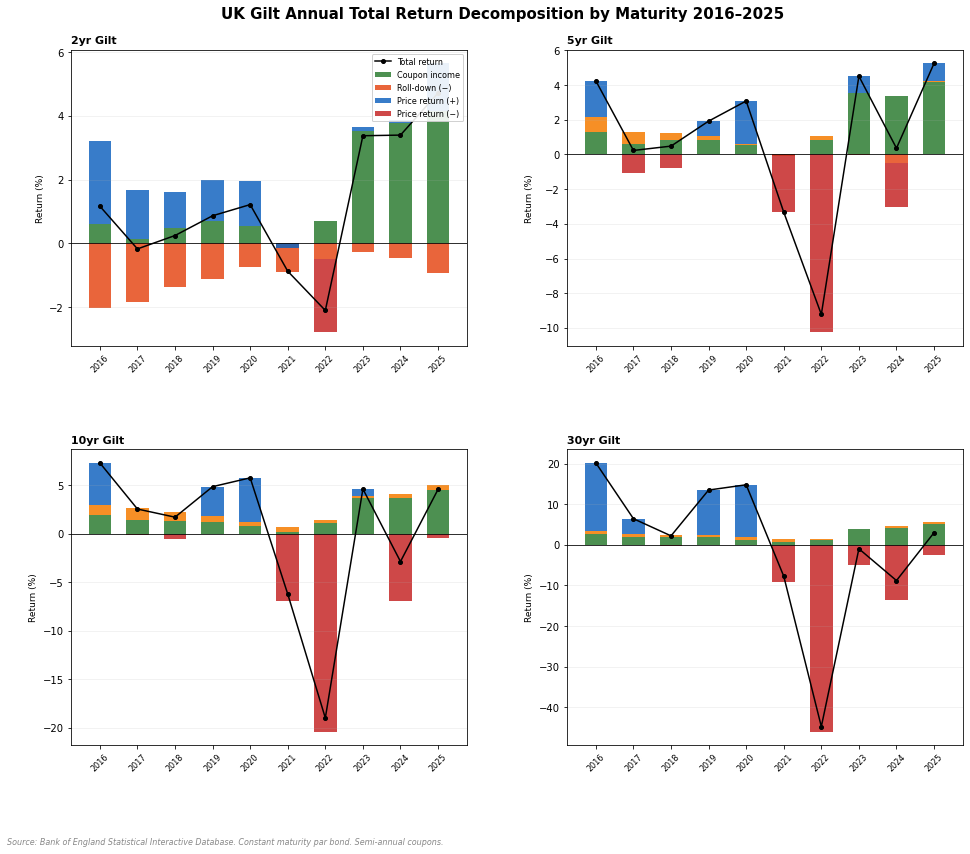

Chart saved.


In [45]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12), facecolor='white')
fig.suptitle('UK Gilt Annual Total Return Decomposition by Maturity 2016–2025',
             fontsize=15, fontweight='bold', y=0.98)
fig.subplots_adjust(hspace=0.35, wspace=0.25, top=0.93)

colors = {
    'Coupon income':   '#2E7D32',
    'Roll-down (+)':   '#F57C00',
    'Roll-down (−)':   '#E64A19',
    'Price return (+)': '#1565C0',
    'Price return (−)': '#C62828',
}

for idx, mat in enumerate(maturities_plot):
    ax = axes[idx // 2][idx % 2]
    ax.set_facecolor('white')

    price    = pivot_price[mat].values
    coupon   = pivot_coupon[mat].values
    rolldown = pivot_rolldown[mat].values
    x        = np.arange(len(years_list))

    # Build stacks carefully — handle negative components explicitly
    # Positive stack builds upward from zero
    # Negative stack builds downward from zero

    pos_bottom = np.zeros(len(x))  # tracks top of positive stack
    neg_bottom = np.zeros(len(x))  # tracks bottom of negative stack

    # --- Coupon — always positive ---
    ax.bar(x, coupon, bottom=pos_bottom, label='Coupon income',
           color=colors['Coupon income'], alpha=0.85, width=0.6)
    pos_bottom += coupon

    # --- Roll-down — can be positive or negative ---
    rd_pos = np.where(rolldown >= 0, rolldown, 0)
    rd_neg = np.where(rolldown < 0, rolldown, 0)

    if rd_pos.any():
        ax.bar(x, rd_pos, bottom=pos_bottom, label='Roll-down (+)',
               color=colors['Roll-down (+)'], alpha=0.85, width=0.6)
        pos_bottom += rd_pos

    if rd_neg.any():
        ax.bar(x, rd_neg, bottom=neg_bottom, label='Roll-down (−)',
               color=colors['Roll-down (−)'], alpha=0.85, width=0.6)
        neg_bottom += rd_neg

    # --- Price return — can be positive or negative ---
    pr_pos = np.where(price >= 0, price, 0)
    pr_neg = np.where(price < 0, price, 0)

    if pr_pos.any():
        ax.bar(x, pr_pos, bottom=pos_bottom, label='Price return (+)',
               color=colors['Price return (+)'], alpha=0.85, width=0.6)

    if pr_neg.any():
        ax.bar(x, pr_neg, bottom=neg_bottom, label='Price return (−)',
               color=colors['Price return (−)'], alpha=0.85, width=0.6)

    # --- Total return line ---
    total = pivot_total[mat].values
    ax.plot(x, total, color='black', linewidth=1.5,
            marker='o', markersize=4, label='Total return', zorder=5)

    ax.axhline(y=0, color='black', linewidth=0.8)
    ax.set_title(f'{mat} Gilt', fontsize=11, fontweight='bold', loc='left')
    ax.set_xticks(x)
    ax.set_xticklabels(years_list, rotation=45, fontsize=8)
    ax.set_ylabel('Return (%)', fontsize=9)
    ax.grid(True, alpha=0.2, axis='y')

    if idx == 0:
        ax.legend(fontsize=8, loc='upper right', framealpha=0.9)

fig.text(0.07, 0.01,
         'Source: Bank of England Statistical Interactive Database. '
         'Constant maturity par bond. Semi-annual coupons.',
         fontsize=8, color='#888888', style='italic')

plt.savefig('outputs/charts/02_annual_total_return_decomposition.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Chart saved.")

## Key Findings — Annual Total Return Analysis

### Headline Result
Over the full 2016–2025 period, cumulative returns were inversely related to maturity:

| Maturity | Cumulative Return 2016–2025 |
|---|---|
| 2yr | +11.87% |
| 5yr | +7.52% |
| 10yr | +3.38% |
| 30yr | −2.06% |

The 2022 inflation shock and rate hiking cycle completely reversed the conventional 
case for long duration outperformance. Over a full decade, the 30yr gilt produced a 
**negative cumulative return** — destroyed by a single two-year period of rising yields.

### Key Observations by Period

**2016 — Post-Brexit yield collapse**
Safe haven demand and BoE emergency easing drove yields sharply lower. Long duration 
rewarded — 30yr returned +20.18%. Dominant force was growth shock, not fiscal risk. 
Contrast with Truss 2022 where the same political uncertainty produced the opposite 
yield direction because fiscal credibility was the dominant concern.

**2021 — First warning signal**
All maturities negative. Markets began pricing inflation and rate hikes before the BoE 
moved. The 30yr at −7.72% was the first serious long-duration loss of the cycle. 
Directly relevant to the transitory narrative analysis in Section 2.

**2022 — Catastrophic for long duration**
30yr: −44.74%. 10yr: −19.01%. 2yr: −2.10%. Largest single-year gilt losses in modern 
history. Short duration was the only meaningful protection. The dispersion between 
2yr and 30yr returns — a 42 percentage point gap — illustrates the cost of 
duration misallocation in a rising rate environment.

**2023–2024 — Long end remains negative despite rate cuts**
The BoE began cutting in August 2024 yet the 30yr produced −0.96% in 2023 and 
−8.79% in 2024. Elevated long-end yields despite easing reflect persistent fiscal 
risk premium and inflation uncertainty — a theme explored in Section 6.

**2025 — Normalisation**
Positive returns across all maturities as the curve stabilised.

### Methodology Note
Returns calculated on a constant maturity par bond basis. Total return decomposed into price return (full DCF 
formula), coupon income (starting yield as proxy), and roll-down (riding the curve 
as maturity shortens). Coupons assumed paid out not reinvested. Full methodology 
documented above.